# 10b — Risk-lane investigation

Five lanes from `backtest_risk.parquet` that are "sim below zero AND actual stayed healthy" — where POP's real inventory survived but our policy would have stocked out:

| lane | sim_min | actual_min | delta |
|---|---|---|---|
| F-04118 NJ | −39k | +91k | −130k |
| F-04130 LA | −27k | +47k | −75k |
| F-04001 NJ | −22k | +10k | −33k |
| F-04114 LA | −17k | +9k | −27k |
| F-76010 LA | −5.5k | +10k | −16k |

**Leads to test:**

1. **LT-variance not priced in** — LT-var formula needs ≥3 PO receipts; if not, we fall back to demand-only SS.
2. **Lumpy / intermittent demand** — F-prefix is POP Ginger Chews + Ferrero; CNY/holiday pulses make normal-dist SS fail.
3. **Wrong XYZ tier** — CV trained on a quiet window → lane classified X when actually Z-bursty.
4. **Parsed lead under-states reality** — if vendor ran slower than the 13-wk default / parsed value, ROP fires late.
5. **Sim starts "behind"** — sim seeds at actual `on_hand` but doesn't pre-load in-flight POs POP had already placed.
6. **Post-as-of demand burst** — actual outflow exceeded training-window p90.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
ART = ROOT / 'pipeline' / 'artifacts'
FIG = ART / 'figures'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Five lanes where actual stayed healthy but sim dipped below zero.
FAIL_LANES = [
    ('F-04118', 'NJ'),
    ('F-04130', 'LA'),
    ('F-04001', 'NJ'),
    ('F-04114', 'LA'),
    ('F-76010', 'LA'),
]

# Upstream artifacts produced by steps 01-10.
risk       = pd.read_parquet(ART / 'backtest_risk.parquet')
alerts_wf  = pd.read_parquet(ART / 'backtest_alerts.parquet')
inv_weekly = pd.read_parquet(ART / 'inv_weekly.parquet')
po         = pd.read_parquet(ART / 'po.parquet')
im         = pd.read_parquet(ART / 'item_master.parquet')
sales      = pd.read_parquet(ART / 'sales.parquet')

inv_weekly['week_start']  = pd.to_datetime(inv_weekly['week_start'])
alerts_wf['as_of_week']   = pd.to_datetime(alerts_wf['as_of_week'])
po['PO Date']             = pd.to_datetime(po['PO Date'])
po['Receipt Date']        = pd.to_datetime(po['Receipt Date'])

DC_MAP = {'1': 'SF', '2': 'NJ', '3': 'LA'}
sales['DC']         = sales['LOCNCODE'].astype(str).map(DC_MAP)
sales['QTY_BASE']   = sales['QUANTITY_adj'].astype(float) * sales['QTYBSUOM'].fillna(1).astype(float)
sales['week_start'] = pd.to_datetime(sales['DOCDATE']).dt.to_period('W-SUN').dt.start_time
outflow_wk = (sales.dropna(subset=['DC'])
                   .groupby(['ITEMNMBR', 'DC', 'week_start'], as_index=False)['QTY_BASE']
                   .sum()
                   .rename(columns={'QTY_BASE': 'outflow'}))

# Quick sanity check — do the 5 lanes all appear in backtest_risk?
focus = risk[risk.apply(lambda r: (r.ITEMNMBR, r.DC) in FAIL_LANES, axis=1)].copy()
focus = focus.sort_values('sim_min').reset_index(drop=True)
print('Focus lanes from backtest_risk.parquet:')
print(focus[['ITEMNMBR','DC','sim_min','sim_final','sim_wks_neg','sim_orders','actual_min','delta_min']].to_string(index=False))


Focus lanes from backtest_risk.parquet:
ITEMNMBR DC  sim_min     sim_final  sim_wks_neg  sim_orders  actual_min  delta_min
 F-04118 NJ -39077.0 142740.000000           18          10     91672.0  -130749.0
 F-04130 LA -27782.0 102144.000000           13          10     47664.0   -75446.0
 F-04001 NJ -22609.0  53155.000000           14           3     10549.0   -33158.0
 F-04114 LA -17742.0  59468.000000           24          16      9496.0   -27238.0
 F-76010 LA  -5568.0   6832.612351           15           6     10668.0   -16236.0


## Lead 1, 3, 4 — Policy diagnostics per lane

For each lane, pull the *final* as-of alert row and show: tier, z_applied, run_rate, σ_d, CV, lead_time_wk, σ_LT, lead_time_source (did LT-variance term activate?), safety_stock, reorder_point.

If `lead_time_source ∈ {parsed, default}` or `lt_std_known=False`, the LT-variance term didn't fire and SS is demand-only. That's Lead 1.


In [2]:
# Last-as-of alert row per lane — the policy in effect at end of backtest.
last_alerts = (alerts_wf[alerts_wf['confidence'] == 'high']
               .sort_values(['ITEMNMBR', 'DC', 'as_of_week'])
               .groupby(['ITEMNMBR', 'DC'], as_index=False)
               .tail(1))

diag_cols = ['ITEMNMBR', 'DC', 'as_of_week',
             'abc', 'xyz', 'tier', 'z_applied',
             'run_rate_wk', 'std_wk', 'cv', 'n_clean_weeks',
             'lead_time_wk', 'lt_std_wk', 'lt_std_known', 'lead_time_source',
             'n_pos', 'n_pos_pool',
             'safety_stock', 'reorder_point', 'forward_cover_wk',
             'reorder_flag', 'suggested_qty']

diag = last_alerts[last_alerts.apply(lambda r: (r.ITEMNMBR, r.DC) in FAIL_LANES, axis=1)][diag_cols]
diag = diag.sort_values(['ITEMNMBR', 'DC']).reset_index(drop=True)

# How much of SS came from demand variance vs LT variance?
# If lt_std_known: SS = z * sqrt(LT*sigma_d^2 + d^2*sigma_LT^2)
# The d^2*sigma_LT^2 term is the LT-contribution; as a fraction of total variance
# it tells you how much of SS is sizing against vendor lateness.
diag['d_term']   = diag['lead_time_wk'] * (diag['std_wk'] ** 2)
diag['lt_term']  = np.where(diag['lt_std_known'],
                            (diag['run_rate_wk'] ** 2) * (diag['lt_std_wk'].fillna(0) ** 2),
                            0.0)
diag['ss_lt_frac'] = diag['lt_term'] / (diag['d_term'] + diag['lt_term']).replace(0, np.nan)

print('=== Policy diagnostics (last-as-of alert per lane) ===')
print(diag.to_string(index=False))


=== Policy diagnostics (last-as-of alert per lane) ===
ITEMNMBR DC as_of_week abc xyz tier  z_applied  run_rate_wk      std_wk       cv  n_clean_weeks  lead_time_wk  lt_std_wk  lt_std_known lead_time_source  n_pos  n_pos_pool  safety_stock  reorder_point  forward_cover_wk  reorder_flag  suggested_qty       d_term      lt_term  ss_lt_frac
 F-04001 NJ 2025-10-13   B   Z   BZ       1.28  1709.036232 2695.205095 1.577032            138     19.285714   3.844158          True       po_history     10          25  17327.639834   50287.624306               6.0          True        29820.0 1.400939e+08 4.316234e+07    0.235530
 F-04114 LA 2025-10-13   A   Y   AY       1.65  2165.106383 1949.780822 0.900547            141     22.000000   5.000136          True       po_history      6          46  23383.167247   71015.507673               6.0          True        50088.0 8.363620e+07 1.171985e+08    0.583557
 F-04118 NJ 2025-10-13   C   Y   CY       1.28  4630.448276 3904.192559 0.843156          

## Lead 2 — Lumpiness / intermittency

Per-lane outflow distribution over the full sales history: share of zero-weeks, mean, std, max, p90, skew. If the burst that killed sim was a one-off above training-window p90, the normal-dist SS couldn't cover it — that's the textbook failure mode for intermittent / lumpy demand.


In [3]:
# Compute a "burst profile" per failing lane over the sim window.
# Week grid is all weeks in inv_weekly (so zero-outflow weeks get counted).
week_grid = pd.Index(sorted(inv_weekly['week_start'].unique()))

rows = []
for sku, dc in FAIL_LANES:
    sim_window = inv_weekly[(inv_weekly.ITEMNMBR == sku) & (inv_weekly.DC == dc)]['week_start']
    if sim_window.empty:
        continue
    w0, w1 = sim_window.min(), sim_window.max()

    # Reindex the outflow Series only (not the full frame) — some cached frames
    # use pyarrow string dtype, which refuses a numeric fill_value.
    lane_series = (outflow_wk[(outflow_wk.ITEMNMBR == sku) & (outflow_wk.DC == dc)]
                              .set_index('week_start')['outflow']
                              .reindex(week_grid, fill_value=0.0))
    lane_series = lane_series.loc[(lane_series.index >= w0) & (lane_series.index <= w1)]

    vals = lane_series.values.astype(float)
    n = len(vals)
    zero_share = float((vals == 0).sum()) / n if n else float('nan')
    mean_ = float(vals.mean()) if n else float('nan')
    std_  = float(vals.std(ddof=0)) if n else float('nan')
    p90_  = float(np.quantile(vals, 0.9)) if n else float('nan')
    max_  = float(vals.max()) if n else float('nan')
    burst_wk = lane_series.idxmax() if n else None
    # Skewness via Pearson's moment coef (no scipy)
    skew_ = float(((vals - mean_) ** 3).mean() / (std_ ** 3)) if (n and std_ > 0) else float('nan')

    # Burst multiplier: max / p90. > 2 means the peak dwarfs the 90th percentile.
    burst_mult = (max_ / p90_) if (p90_ and p90_ > 0) else float('nan')

    rows.append({
        'ITEMNMBR':   sku,
        'DC':         dc,
        'n_weeks':    n,
        'zero_share': round(zero_share, 3),
        'mean':       round(mean_, 1),
        'std':        round(std_, 1),
        'cv_full':    round((std_ / mean_) if mean_ > 0 else float('nan'), 2),
        'p90':        round(p90_, 1),
        'max':        round(max_, 1),
        'burst_mult': round(burst_mult, 2),
        'skew':       round(skew_, 2),
        'burst_week': pd.Timestamp(burst_wk).date() if burst_wk is not None else None,
    })

burst = pd.DataFrame(rows)
print('=== Outflow burst profile over sim window ===')
print(burst.to_string(index=False))
print('\nReading guide:')
print('  zero_share > 0.2  → intermittent (normal-dist SS fails per the skill)')
print('  burst_mult > 2    → peak far above p90, hard to size SS for')
print('  skew > 2          → right-skewed (rare huge pulls)')


=== Outflow burst profile over sim window ===
ITEMNMBR DC  n_weeks  zero_share   mean    std  cv_full    p90     max  burst_mult  skew burst_week
 F-04118 NJ      173       0.260 3348.9 3789.9     1.13 8537.4 17685.0        2.07  1.38 2024-08-26
 F-04130 LA      173       0.133 3650.3 3336.6     0.91 7770.4 18324.0        2.36  1.38 2025-08-25
 F-04001 NJ      173       0.133 1578.1 3270.6     2.07 3628.4 29451.0        8.12  5.87 2025-10-20
 F-04114 LA      173       0.116 2007.2 1998.9     1.00 4689.6  9432.0        2.01  1.35 2024-11-18
 F-76010 LA      173       0.052  478.3  653.8     1.37 1233.6  4128.0        3.35  2.96 2025-11-10

Reading guide:
  zero_share > 0.2  → intermittent (normal-dist SS fails per the skill)
  burst_mult > 2    → peak far above p90, hard to size SS for
  skew > 2          → right-skewed (rare huge pulls)


## Lead 5 — Sim starts "behind" vs actual

Sim seeds at actual `on_hand_est` at the first as-of week but doesn't pre-load any in-flight POs POP had already placed. Count POs with `PO Date < first_asof <= Receipt Date` — if POP had multiple POs in flight when the sim started, the sim is carrying a real gap on day 1.


In [4]:
# Need to determine which POs were "in-flight" at first as-of week.
# A PO is in-flight if PO Date < first_asof_week <= Receipt Date.
# Quantity in-flight = qty received after first_asof_week (i.e. the POs
# that hadn't landed yet when sim seeded).

# First as-of week per lane.
first_asof = (alerts_wf[alerts_wf['confidence'] == 'high']
              .groupby(['ITEMNMBR', 'DC'])['as_of_week'].min().reset_index())

# Column name detection — po.parquet uses the original PO file's column
# names ('Item Number', 'Location Code', 'QTY Shipped'), not normalized
# ones. Nail this down once at the top.
po_cols = set(po.columns)
item_col = next(c for c in ('Item Number', 'ITEMNMBR') if c in po_cols)
loc_col  = next(c for c in ('Location Code', 'LOCNCODE', 'DC') if c in po_cols)
qty_col  = next(c for c in ('QTY Shipped', 'Qty Shipped', 'QTY Received', 'Qty Received') if c in po_cols)
print(f'PO cols detected: item={item_col}  loc={loc_col}  qty={qty_col}')

# Map LOCNCODE-like → DC label once so all downstream filters can use po['DC'].
po['DC'] = po[loc_col].astype(str).map(DC_MAP)

rows = []
for sku, dc in FAIL_LANES:
    f = first_asof[(first_asof.ITEMNMBR == sku) & (first_asof.DC == dc)]
    if f.empty:
        continue
    w0 = f.iloc[0]['as_of_week']
    inv_row = inv_weekly[(inv_weekly.ITEMNMBR == sku) & (inv_weekly.DC == dc) & (inv_weekly.week_start == w0)]
    seed = float(inv_row['on_hand_est'].iloc[0]) if len(inv_row) else float('nan')

    # In-flight POs at sim start.
    mask = (
        (po[item_col] == sku)
        & (po['DC'] == dc)
        & (po['PO Date'] < w0)
        & (po['Receipt Date'] >= w0)
    )
    in_flight_pos = po.loc[mask].copy()
    n_inflight = len(in_flight_pos)
    qty_inflight = float(in_flight_pos[qty_col].sum()) if n_inflight else 0.0

    # First PO POP actually placed AFTER w0 — the "when would sim get help" marker.
    first_after_mask = (po[item_col] == sku) & (po['DC'] == dc) & (po['PO Date'] >= w0)
    if first_after_mask.any():
        first_after = po.loc[first_after_mask].sort_values('PO Date').iloc[0]
        first_after_date = pd.Timestamp(first_after['PO Date'])
        first_after_qty  = float(first_after[qty_col])
    else:
        first_after_date = None
        first_after_qty  = float('nan')
    rows.append({
        'ITEMNMBR':          sku,
        'DC':                dc,
        'first_asof':        pd.Timestamp(w0).date(),
        'seed_on_hand':      round(seed, 0),
        'n_inflight_pos':    n_inflight,
        'qty_inflight':      round(qty_inflight, 0),
        'first_po_after':    first_after_date.date() if first_after_date is not None else None,
        'first_po_qty':      round(first_after_qty, 0) if first_after_qty == first_after_qty else None,
    })

seed_diag = pd.DataFrame(rows)
print('\n=== Starting-inventory gap diagnostics ===')
print(seed_diag.to_string(index=False))
print('\nReading guide:')
print('  qty_inflight > seed_on_hand means the sim starts with a hidden deficit')
print('  that only reveals itself as those POs landed in actual but not in sim.')


PO cols detected: item=Item Number  loc=Location Code  qty=QTY Shipped

=== Starting-inventory gap diagnostics ===
ITEMNMBR DC first_asof  seed_on_hand  n_inflight_pos  qty_inflight first_po_after  first_po_qty
 F-04118 NJ 2023-07-24      424926.0               0           0.0     2023-08-29        3918.0
 F-04130 LA 2023-04-03      477714.0               0           0.0     2023-12-11        1775.0
 F-04001 NJ 2023-04-03      234149.0               0           0.0     2023-05-25        2400.0
 F-04114 LA 2023-04-03      178451.0               0           0.0     2023-10-20        3918.0
 F-76010 LA 2023-12-11       64885.0               4        1450.0     2024-07-22         200.0

Reading guide:
  qty_inflight > seed_on_hand means the sim starts with a hidden deficit
  that only reveals itself as those POs landed in actual but not in sim.


## Timeline plots — one per lane

For each failing lane overlay: actual `on_hand_est`, outflow (bar), reorder_point over time, alert fires, actual PO receipts. This makes the failure visible: where did sim and actual diverge, and why?


saved: /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/figures/risk_investigation_timelines.png


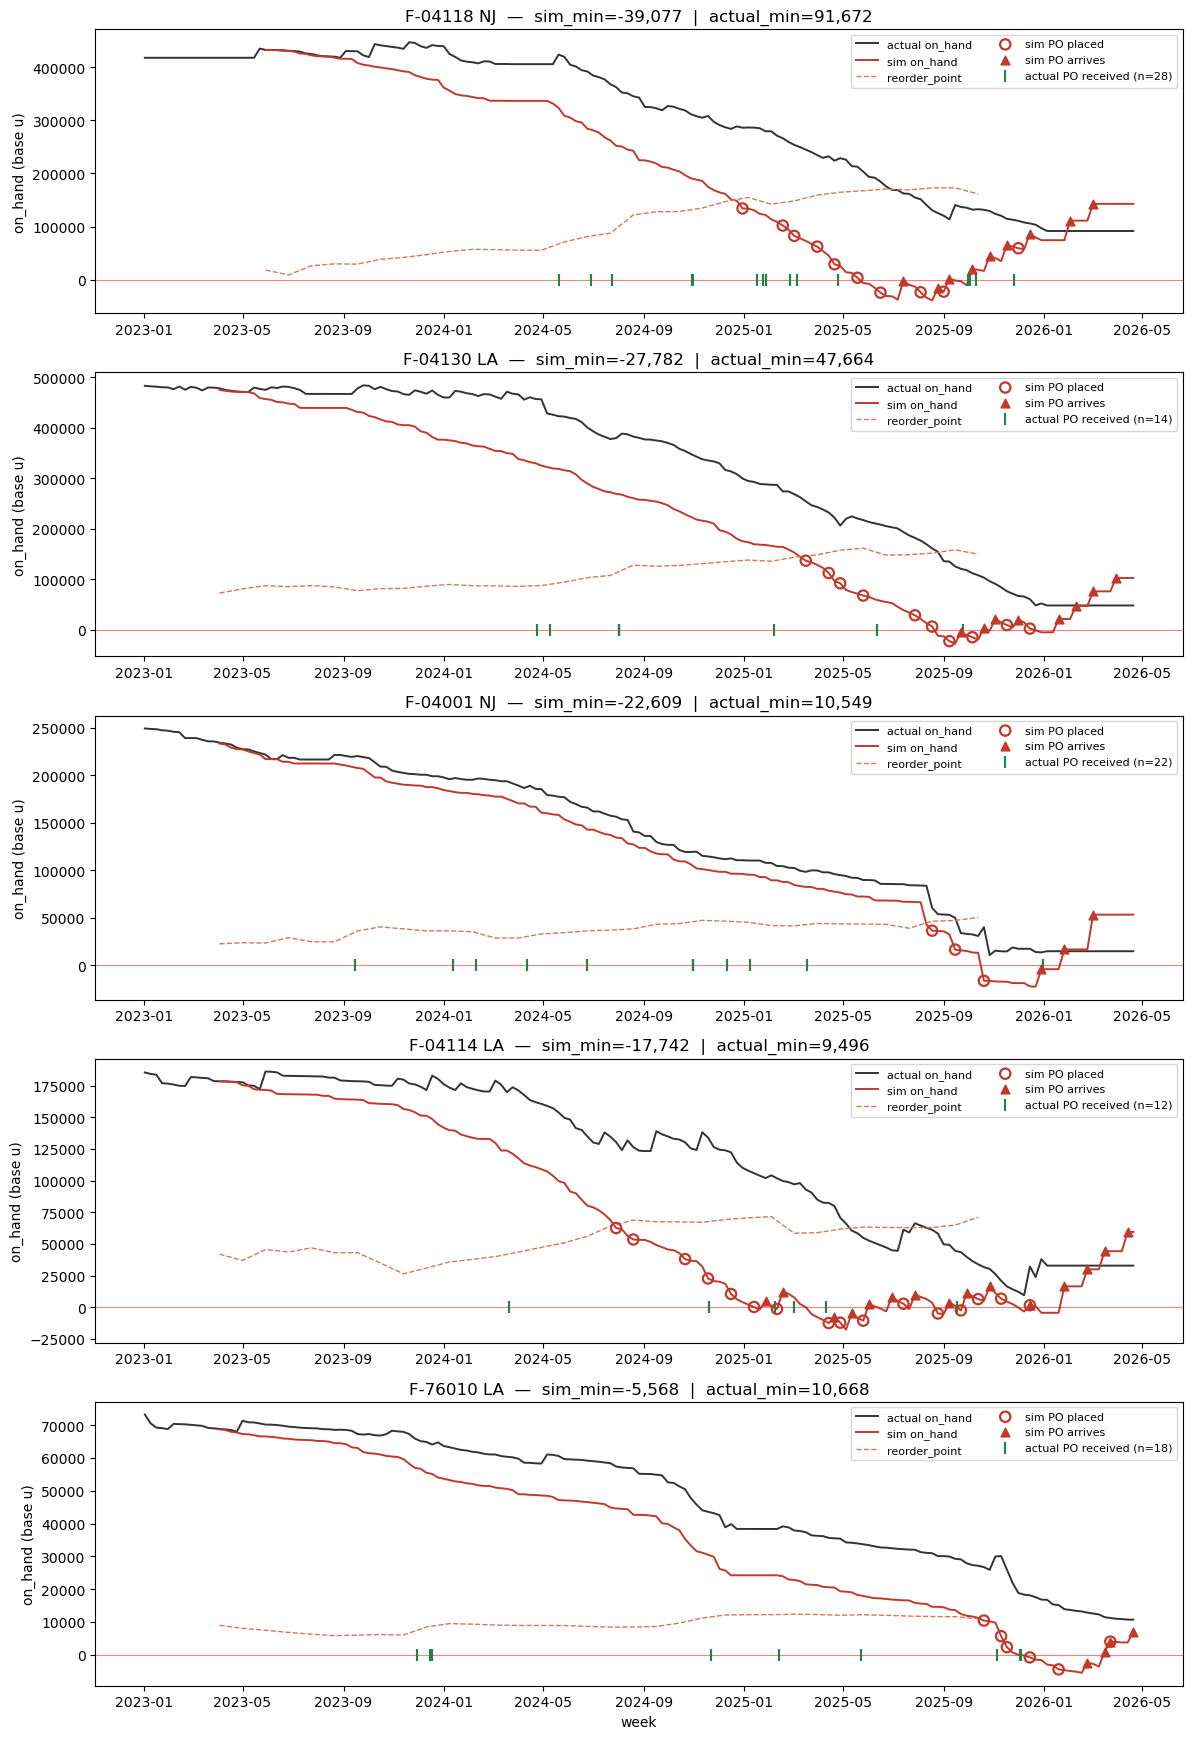

In [5]:
# Re-run simulate_followed for the failing lanes (need the sim curves for plotting).
# Pull helpers from the backtest notebook's logic: inline a minimal copy so this
# notebook is self-contained.
from src.reorder import FORWARD_COVER_WEEKS, _round_up_case


def simulate_followed(lane_sku, lane_dc, alerts_frame, outflow_wk, inv_weekly):
    al = alerts_frame[(alerts_frame.ITEMNMBR == lane_sku) & (alerts_frame.DC == lane_dc)].sort_values('as_of_week')
    if al.empty:
        return pd.DataFrame()
    alerts_by_week = {r['as_of_week']: r for _, r in al.iterrows()}
    asof_sorted = sorted(alerts_by_week.keys())
    start_week = al['as_of_week'].min()
    inv_lane = inv_weekly[(inv_weekly.ITEMNMBR == lane_sku) & (inv_weekly.DC == lane_dc)].sort_values('week_start')
    seed_row = inv_lane[inv_lane['week_start'] == start_week]
    if seed_row.empty:
        return pd.DataFrame()
    on_hand = float(seed_row['on_hand_est'].iloc[0])
    outflow = (outflow_wk[(outflow_wk.ITEMNMBR == lane_sku) & (outflow_wk.DC == lane_dc)]
                         .set_index('week_start')['outflow'])
    weeks = inv_lane[inv_lane['week_start'] >= start_week]['week_start'].tolist()
    po_schedule = {}
    rows = []
    for w in weeks:
        po_arr = po_schedule.pop(w, 0.0)
        on_hand += po_arr
        on_hand -= float(outflow.get(w, 0.0))
        current = None
        for aw in asof_sorted:
            if aw <= w:
                current = aw
            else:
                break
        po_qty = 0.0
        fires = False
        if current is not None:
            a = alerts_by_week[current]
            rp = float(a['reorder_point']) if pd.notna(a['reorder_point']) else float('nan')
            rr = float(a['run_rate_wk']) if pd.notna(a['run_rate_wk']) else 0.0
            cp = float(a['case_pack']) if pd.notna(a['case_pack']) else 1.0
            lead = float(a['lead_time_wk']) if pd.notna(a['lead_time_wk']) else 13.0
            ip = on_hand + sum(po_schedule.values())
            if pd.notna(rp) and ip < rp:
                raw = max(0.0, rp + FORWARD_COVER_WEEKS * rr - ip)
                po_qty = _round_up_case(raw, cp)
                if po_qty > 0:
                    arr = w + pd.Timedelta(weeks=int(round(lead)))
                    po_schedule[arr] = po_schedule.get(arr, 0.0) + po_qty
                    fires = True
        rows.append({'week_start': w, 'on_hand_sim': on_hand, 'outflow': float(outflow.get(w, 0.0)),
                     'po_arrives': po_arr, 'alert_fires': fires, 'po_ordered': po_qty})
    return pd.DataFrame(rows)


fig, axes = plt.subplots(len(FAIL_LANES), 1, figsize=(12, 3.5 * len(FAIL_LANES)), sharex=False)
if len(FAIL_LANES) == 1:
    axes = [axes]

for ax, (sku, dc) in zip(axes, FAIL_LANES):
    sim = simulate_followed(sku, dc, alerts_wf, outflow_wk, inv_weekly)
    actual = inv_weekly[(inv_weekly.ITEMNMBR == sku) & (inv_weekly.DC == dc)].sort_values('week_start')
    lane_alerts = alerts_wf[(alerts_wf.ITEMNMBR == sku) & (alerts_wf.DC == dc)].sort_values('as_of_week')

    # Primary axis: on_hand (actual + sim)
    ax.plot(actual['week_start'], actual['on_hand_est'], color='#333', linewidth=1.4, label='actual on_hand')
    if not sim.empty:
        ax.plot(sim['week_start'], sim['on_hand_sim'], color='#c0392b', linewidth=1.4, label='sim on_hand')
    ax.axhline(0, color='red', linewidth=0.8, alpha=0.5)
    # Reorder_point plot (from alert rows)
    ax.plot(lane_alerts['as_of_week'], lane_alerts['reorder_point'], color='#d97757', linestyle='--', linewidth=1, label='reorder_point')

    # Sim alert fires + sim PO arrivals
    if not sim.empty:
        fires = sim[sim['alert_fires']]
        arrives = sim[sim['po_arrives'] > 0]
        ax.scatter(fires['week_start'], fires['on_hand_sim'], color='#c0392b', marker='o', s=55,
                   facecolors='none', linewidths=1.6, zorder=5, label='sim PO placed')
        ax.scatter(arrives['week_start'], arrives['on_hand_sim'], color='#c0392b', marker='^', s=40, zorder=5, label='sim PO arrives')

    # Actual PO receipts (POP's real buys)
    po_lane = po[(po[item_col] == sku) & (po['DC'] == dc)]
    po_lane = po_lane[(po_lane['Receipt Date'] >= actual['week_start'].min()) &
                      (po_lane['Receipt Date'] <= actual['week_start'].max())]
    if len(po_lane):
        ax.scatter(po_lane['Receipt Date'],
                   [0] * len(po_lane),
                   color='#1e8449', marker='|', s=80, zorder=4, label=f'actual PO received (n={len(po_lane)})')

    ax.set_title(f'{sku} {dc}  —  sim_min={sim.on_hand_sim.min():,.0f}  |  actual_min={actual.on_hand_est.min():,.0f}')
    ax.set_ylabel('on_hand (base u)')
    ax.legend(loc='upper right', fontsize=8, ncol=2)

axes[-1].set_xlabel('week')
fig.tight_layout()
out = FIG / 'risk_investigation_timelines.png'
fig.savefig(out, dpi=120)
print(f'saved: {out}')
plt.show()


## Verdict — which lead fits each lane?

Join the diagnostics back together and assign a primary cause per lane, plus a proposed fix.


In [6]:
# Merge the three diagnostic tables and assign a primary cause heuristically.
verdict = (diag.merge(burst, on=['ITEMNMBR', 'DC'], how='left')
               .merge(seed_diag[['ITEMNMBR','DC','seed_on_hand','qty_inflight','n_inflight_pos']],
                      on=['ITEMNMBR','DC'], how='left'))

def classify(r):
    leads = []
    # L5: sim starts behind — in-flight POs exceed 20% of seed
    if pd.notna(r.get('qty_inflight')) and r.get('seed_on_hand') and r['seed_on_hand'] > 0:
        if r['qty_inflight'] / max(r['seed_on_hand'], 1) >= 0.2:
            leads.append('L5_inflight_gap')
    # L1: LT variance not priced in
    if not r['lt_std_known']:
        leads.append('L1_no_lt_variance')
    # L2: lumpy / intermittent
    if pd.notna(r.get('zero_share')) and r['zero_share'] >= 0.2:
        leads.append('L2_intermittent')
    if pd.notna(r.get('burst_mult')) and r['burst_mult'] >= 2.0:
        leads.append('L2_burst')
    # L3: wrong tier — X or Y classification despite high CV
    if r['xyz'] in ('X','Y') and pd.notna(r.get('cv_full')) and r['cv_full'] >= 1.0:
        leads.append('L3_tier_understated')
    # L4: lead fell back to parsed or default
    if r['lead_time_source'] in ('parsed', 'default'):
        leads.append('L4_lead_fallback')
    return ', '.join(leads) if leads else 'none_obvious'

verdict['diagnosis'] = verdict.apply(classify, axis=1)

show = ['ITEMNMBR','DC','tier','z_applied',
        'lead_time_wk','lead_time_source','n_pos','n_pos_pool','lt_std_known','ss_lt_frac',
        'run_rate_wk','cv','cv_full','zero_share','burst_mult','skew','burst_week',
        'seed_on_hand','qty_inflight','n_inflight_pos',
        'safety_stock','reorder_point','diagnosis']
print('=== Verdict table ===')
with pd.option_context('display.width', 200, 'display.max_columns', None):
    print(verdict[show].to_string(index=False))

verdict.to_parquet(ART / 'risk_investigation_verdict.parquet')
print(f'\nsaved: {ART / "risk_investigation_verdict.parquet"}')


=== Verdict table ===
ITEMNMBR DC tier  z_applied  lead_time_wk lead_time_source  n_pos  n_pos_pool  lt_std_known  ss_lt_frac  run_rate_wk       cv  cv_full  zero_share  burst_mult  skew burst_week  seed_on_hand  qty_inflight  n_inflight_pos  safety_stock  reorder_point                                      diagnosis
 F-04001 NJ   BZ       1.28     19.285714       po_history     10          25          True    0.235530  1709.036232 1.577032     2.07       0.133        8.12  5.87 2025-10-20      234149.0           0.0               0  17327.639834   50287.624306                                       L2_burst
 F-04114 LA   AY       1.65     22.000000       po_history      6          46          True    0.583557  2165.106383 0.900547     1.00       0.116        2.01  1.35 2024-11-18      178451.0           0.0               0  23383.167247   71015.507673                  L2_burst, L3_tier_understated
 F-04118 NJ   CY       1.28     25.000000       po_history     13          24          Tru